In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [6]:
# Load dataset
df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1', sep=';')

In [23]:
if 'ï»¿InvoiceNo' in df.columns:
    df = df.rename(columns={'ï»¿InvoiceNo': 'InvoiceNo'})


In [24]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [25]:
# DATA CLEANING
# ----------------------
df = df.dropna()
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]


In [26]:
# Create Total Price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [27]:
# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],dayfirst=True)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
 9   Month        397884 non-null  period[M]     
dtypes: datetime64[ns](1), float64(3), int64(1), object(4), period[M](1)
memory usage: 33.4+ MB


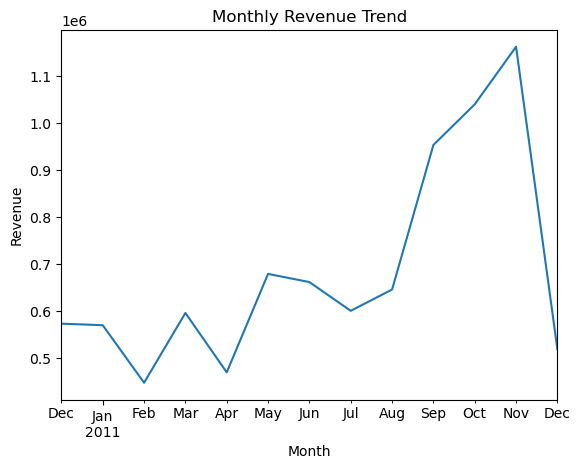

In [29]:
# REVENUE ANALYSIS
# ----------------------
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['TotalPrice'].sum()

plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


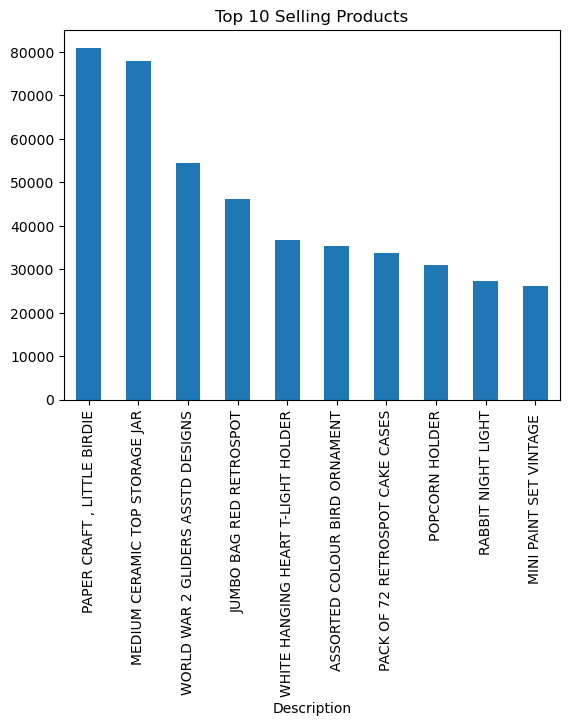

In [30]:
# TOP PRODUCTS
# ----------------------
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Selling Products")
plt.show()

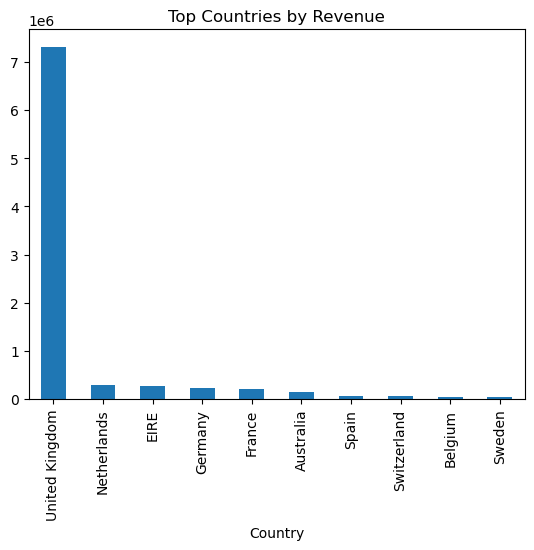

In [31]:
# COUNTRY ANALYSIS
# ----------------------
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure()
country_sales.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.show()

In [32]:
# RFM ANALYSIS
# ----------------------
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [38]:
# RFM Scoring
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 4, labels=False,duplicates='drop')+1
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=False,duplicates='drop')+1

rfm['RFM_Score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)



In [39]:
# CUSTOMER SEGMENTS
# ----------------------
def segment(score):
    if score >= 10:
        return "High Value"
    elif score >= 6:
        return "Mid Value"
    else:
        return "Low Value"

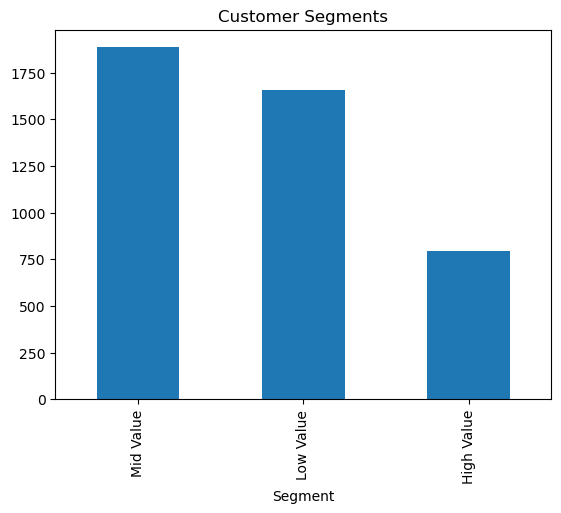

In [40]:
rfm['Segment'] = rfm['RFM_Score'].apply(segment)

segment_counts = rfm['Segment'].value_counts()

plt.figure()
segment_counts.plot(kind='bar')
plt.title("Customer Segments")
plt.show()


In [42]:
# SAVE OUTPUT
# ----------------------
rfm.to_csv("rfm_output.csv")

print("Analysis Completed Successfully!")

Analysis Completed Successfully!
